# Buying-Intent Classifier — Ablation Study (last-turn-removed / pre-reversal / first-half)

This notebook is a **companion, not a replacement**, for
`Generic/generic-v14-antiphony.ipynb`. That notebook trains the full
dual-stream "antiphony" model (roberta-base / deberta-v3-base / todbert)
plus one ablation control (`last-turn-only`: encoder → mean-pool → linear
head, fed **only** the final Buyer turn). Its run is documented end-to-end in
`Generic/ran-nb/AUDIT_generic-antiphony.md`.

That audit's headline finding is that the full model and the last-turn-only
control score **almost identically** (macro-F1 0.9733 vs 0.9732, gap
+0.0001). That comparison shows the label is recoverable from the closing
turn — it does **not** by itself show whether the model can recover the
label when the closing turn is **hidden**. Those are different questions:

- `last-turn-only` (existing, in the source notebook): *is the last turn
  sufficient?* → yes, almost entirely.
- `last-turn-removed` (new, here): *is the last turn necessary?* → this
  notebook's central question.

If a model trained without ever seeing the closing turn still scores nearly
as well as the full model, dialogue context genuinely substitutes for the
closing line. If it collapses, the closing turn is carrying information nothing
else in the dialogue restates — which is the harder, more informative ablation,
and the one that will actually discriminate once reversal dialogues (dialogues
whose sentiment flips near the end) are added to the corpus.

## Design choice — documented up front

**This notebook does not re-run the full dual-stream `AntiphonyClassifier`.**
It reuses the existing audited numbers for the majority baseline, the full
model, and the last-turn-only control (hardcoded below, cited to
`AUDIT_generic-antiphony.md`, §4 and §6) as fixed reference points, and
spends its compute on the **three new ablation controls** plus the
reversal-flip diagnostic. Reasons:

1. The full architecture is unchanged code (§2.1 of the audit) — re-running
   it here would not produce a new finding, only reproduce the audited run
   (modulo train/val/test split RNG, which is seeded identically below so
   the reference numbers remain the correct comparison point).
2. Keeping this notebook's own model class identical to the existing
   `LastTurnClassifier` control (encoder → masked mean-pool → linear head)
   makes every row in the final comparison table an apples-to-apples input
   ablation on the **same minimal architecture** — the only thing that
   changes between rows is *what text the model is allowed to see*, which is
   exactly what this study is measuring. Mixing in the full dual-stream
   model for the new rows would confound "architecture" with "input" as two
   simultaneous variables.
3. Practically: this notebook is meant to be run **three times** (§ config
   below) — once on the current 500, once on a 200-dialogue reversal-only
   corpus, and once on the 700-dialogue combination. Three full dual-stream
   training runs (25 epochs × 3 encoders each) would be far more expensive
   than three lightweight single-turn-classifier runs, for a question that
   the minimal architecture answers just as validly.

If a future run wants the full dual-stream model's last-turn-removed score
specifically, `AntiphonyClassifier` can be imported unchanged from the
source notebook — the dataset/collate plumbing in §4 below is compatible with
it (same `[Merchant]`/`[Buyer]` marker convention, same `DialogueIntentDataset`
pattern). That is a valid extension, not a redesign.


## 0. Running this notebook

Same conventions as `generic-v14-antiphony.ipynb`:

- **Local**: run from the repo root or `Generic/`; the fuzzy file search
  under `CONFIG["search_roots"]` finds `final.json` / `Buying_Intent_Label.csv`
  automatically.
- **Kaggle**: add the dataset as an input, `/kaggle/input` is searched first.
- Outputs (CSVs, PNGs, JSON run report) are written to `Generic/ran-nb/`
  (or `CONFIG["out_dir"]`), named `<artefact>_<run_tag>.<ext>` — the same
  convention the source notebook uses, so files from both notebooks sit
  side by side without collisions.


## 1. Imports & global config

In [1]:
# =============================================================
# 1. IMPORTS & GLOBAL CONFIG
# =============================================================
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import re, json, glob, gc, time, warnings, random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ---- CONFIG: the only block you should need to touch -----------------
# To re-run this notebook against a different arm of the ablation study
# (see Generic/ABLATION_STUDY_GUIDELINE.md), change ONLY "dataset_path"
# and "run_tag" below, then Restart & Run All. Nothing else in this
# notebook needs to change.
CONFIG = {
    # ---- Arm switch -----------------------------------------------
    # Arm A (default): the existing 500-dialogue corpus.
    #   "dataset_path": "final.json", "run_tag": "generic-ablation-v1"
    # Arm B: reversal dialogues only (once generated).
    #   "dataset_path": "Dataset/reversal_dataset.json",
    #   "run_tag": "generic-ablation-reversal-only"
    # Arm C: original + reversal combined.
    #   "dataset_path": "Dataset/final_plus_reversal.json",
    #   "run_tag": "generic-ablation-combined"
    "dataset_path": "final.json",
    "run_tag": "generic-ablation-v1",

    # Same fuzzy recursive search convention as the source notebook. If
    # "dataset_path" is a bare filename (no "/"), it is searched for under
    # search_roots by filename; if it contains a "/", it is resolved
    # relative to search_roots in order (first existing match wins).
    "search_roots": ["/kaggle/input", "/kaggle/working", "/workspace", "/data",
                     ".", "..", "../..", "Generic", "../Generic"],

    "out_dir": "/kaggle/working" if os.path.isdir("/kaggle/working") else "./outputs",

    "binary_classes": ["no", "yes"],

    # The single encoder used for every ablation control in this notebook
    # (matches CONFIG["ablation_encoder"] in the source notebook, so the
    # last-turn-only number cited below is a fair comparison point).
    "ablation_encoder": {"name": "roberta-base", "hf_id": "roberta-base"},
    "ablation_max_len": 64,
    "ablation_max_len_full": 512,   # for first-half-only, which can be longer
    "ablation_epochs": 15,
    "ablation_batch_size": 16,

    "train_frac": 0.70,
    "val_frac": 0.15,
    "test_frac": 0.15,

    "lr": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.06,
    "max_grad_norm": 1.0,

    "cb_beta": 0.999,
    "focal_gamma": 2.0,

    "checkpoint_dir_name": "checkpoints_generic-ablation",
}

os.makedirs(CONFIG["out_dir"], exist_ok=True)
os.makedirs(os.path.join(CONFIG["out_dir"], CONFIG["checkpoint_dir_name"]), exist_ok=True)
print(json.dumps(CONFIG, indent=2))


Using device: cuda
GPU: Tesla T4
{
  "dataset_path": "final.json",
  "run_tag": "generic-ablation-v1",
  "search_roots": [
    "/kaggle/input",
    "/kaggle/working",
    "/workspace",
    "/data",
    ".",
    "..",
    "../..",
    "Generic",
    "../Generic"
  ],
  "out_dir": "/kaggle/working",
  "binary_classes": [
    "no",
    "yes"
  ],
  "ablation_encoder": {
    "name": "roberta-base",
    "hf_id": "roberta-base"
  },
  "ablation_max_len": 64,
  "ablation_max_len_full": 512,
  "ablation_epochs": 15,
  "ablation_batch_size": 16,
  "train_frac": 0.7,
  "val_frac": 0.15,
  "test_frac": 0.15,
  "lr": 2e-05,
  "weight_decay": 0.01,
  "warmup_ratio": 0.06,
  "max_grad_norm": 1.0,
  "cb_beta": 0.999,
  "focal_gamma": 2.0,
  "checkpoint_dir_name": "checkpoints_generic-ablation"
}


In [2]:
# ============================================================= ARM
CONFIG["dataset_path"] = 'reversal_dataset_v3.json'
CONFIG["run_tag"] = 'generic-abl-b-strict'
CONFIG["checkpoint_dir_name"] = "checkpoints_" + 'generic-abl-b-strict'
os.makedirs(os.path.join(CONFIG["out_dir"], CONFIG["checkpoint_dir_name"]), exist_ok=True)

# left truncation: the source architecture drops the EARLIEST turns and
# keeps the most recent (ultimate-capstone-final-v14.ipynb cell 16).
CONFIG["truncation_side"] = "left"
from transformers import AutoTokenizer as _AutoTokenizer
_orig_from_pretrained = _AutoTokenizer.from_pretrained


def _left_trunc(*a, **k):
    tok = _orig_from_pretrained(*a, **k)
    tok.truncation_side = CONFIG["truncation_side"]
    return tok


AutoTokenizer.from_pretrained = staticmethod(_left_trunc)
_p = AutoTokenizer.from_pretrained(CONFIG["ablation_encoder"]["hf_id"])
assert _p.truncation_side == "left"
print("ARM " + CONFIG["run_tag"] + " | dataset=" + CONFIG["dataset_path"]
      + " | truncation_side=" + repr(_p.truncation_side))

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

ARM generic-abl-b-strict | dataset=reversal_dataset_v3.json | truncation_side='left'


## 2. Load the dataset (JSON, not the CSV)

Unlike the source notebook (which reads the pre-built
`Buying_Intent_Label.csv`), this notebook reads the **raw JSON** directly.
Reason: the new ablation controls need per-turn structure
(`turns[].turn_id`, `turns[].role`, and — once present —
`reversal_turn_id` / `turns[].sentiment_tag`) that the flattened CSV's
`dialogue_text` string does not carry losslessly enough to re-derive
cheaply and safely. Working from JSON also means this notebook needs no
`build_csv_from_json` fallback: it *is* the JSON reader.

The resulting per-dialogue records are still turned into the same
`[Merchant]` / `[Buyer]`-marked flat string used everywhere else in this
project (see `ROLE_MARKER` below) so `split_into_utterances`-style parsing
stays identical to the source notebook's, and any function copy-pasted
between the two notebooks behaves the same way.


In [3]:
# =============================================================
# 2. DATA DISCOVERY & LOADING (JSON)
# =============================================================
ROLE_MARKER = {"Merchant": "[Merchant]", "Buyer": "[Buyer]"}


def find_dataset_path(path_hint, search_roots):
    """Resolve CONFIG["dataset_path"] against search_roots.

    If path_hint already exists as given (relative to cwd), use it as-is.
    Otherwise search each root for a file ending in the same basename."""
    if os.path.isfile(path_hint):
        return path_hint
    target = os.path.basename(path_hint)
    for root in search_roots:
        cand = os.path.join(root, path_hint)
        if os.path.isfile(cand):
            return cand
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        for dirpath, _dirnames, filenames in os.walk(root):
            for fn in filenames:
                if fn == target:
                    return os.path.join(dirpath, fn)
    raise FileNotFoundError(
        f"Could not locate {path_hint!r} under {search_roots}. "
        "Check CONFIG['dataset_path'] and CONFIG['search_roots'].")


dataset_path = find_dataset_path(CONFIG["dataset_path"], CONFIG["search_roots"])
print(f"Loading dataset from: {dataset_path}")

with open(dataset_path, encoding="utf-8") as f:
    raw_dialogues = json.load(f)
print(f"Loaded {len(raw_dialogues)} dialogues.")


def dialogue_to_marked_text(d):
    parts = []
    for t in d["turns"]:
        marker = ROLE_MARKER.get(t["role"])
        if marker is None:
            raise ValueError(f"unmapped role {t['role']!r} in {d['dialogue_id']}")
        txt = " ".join(str(t["text"]).split())
        if txt:
            parts.append(f"{marker} {txt}")
    return "\r\n ".join(parts)


rows = []
for d in raw_dialogues:
    rows.append({
        "dialogue_id": d["dialogue_id"],
        "text": dialogue_to_marked_text(d),
        "binary_label": str(d["labels"]["buying_intent"]).strip().lower(),
        "outcome_category": d["labels"].get("outcome_category", ""),
        "archetype": d.get("archetype", ""),
        "product": d.get("product", ""),
        "category": d.get("category", ""),
        # NEW fields -- present only on reversal-tagged dialogues (Arm B/C).
        # Absent/None on the current 500-dialogue corpus (Arm A) -- every
        # section below that reads these handles that gracefully.
        "reversal_type": d["labels"].get("reversal_type"),
        "reversal_turn_id": d.get("reversal_turn_id"),
        "turns": d["turns"],   # kept as a raw list for the new ablations
    })
df = pd.DataFrame(rows)

df["binary_label"] = df["binary_label"].fillna("").astype(str).str.strip().str.lower()
bad_binary = ~df["binary_label"].isin(CONFIG["binary_classes"])
if bad_binary.any():
    print(f"WARNING: dropping {int(bad_binary.sum())} row(s) with out-of-vocabulary binary_label.")
    df = df.loc[~bad_binary].reset_index(drop=True)
df["binary_id"] = df["binary_label"].map({c: i for i, c in enumerate(CONFIG["binary_classes"])})

n_reversal_tagged = df["reversal_turn_id"].notna().sum()
print(f"\nLoaded {len(df)} labeled dialogues after cleaning.")
print(f"Dialogues carrying reversal_turn_id: {n_reversal_tagged}/{len(df)}")
df[["dialogue_id", "binary_label", "outcome_category", "reversal_type"]].head()


Loading dataset from: /kaggle/input/datasets/ahmadmuhammad26/generic-antiphony-ablation/reversal_dataset_v3.json
Loaded 200 dialogues.

Loaded 200 labeled dialogues after cleaning.
Dialogues carrying reversal_turn_id: 130/200


,dialogue_id,binary_label,outcome_category,reversal_type
0,REV_001,yes,PURCHASE_COMMITTED,resistance_to_agreement
1,REV_002,yes,PURCHASE_COMMITTED,resistance_to_agreement
2,REV_003,yes,PURCHASE_COMMITTED,resistance_to_agreement
3,REV_004,yes,PURCHASE_COMMITTED,resistance_to_agreement
4,REV_005,yes,PURCHASE_COMMITTED,resistance_to_agreement


In [4]:
# ============================================================= STRICT QUARANTINE
# Remove every reversal-related field from the modelling frame -- by
# DELETION, not by setting it to None, so accidental use fails loudly.
# =============================================================

def _opening_tag(ts):
    for t in sorted(ts, key=lambda t: t["turn_id"]):
        if t["role"] == "Buyer":
            return t.get("sentiment_tag")
    return None


# Side table: the ONLY place reversal annotation survives. Keyed by
# dialogue_id, used for arm 7c's cut points and for post-hoc grouping.
reversal_meta = pd.DataFrame({
    "dialogue_id": df["dialogue_id"],
    "reversal_type": df["reversal_type"],
    "reversal_turn_id": df["reversal_turn_id"],
    "opening_tag": [_opening_tag(ts) for ts in df["turns"]],
}).set_index("dialogue_id")
print("side table built for " + str(len(reversal_meta)) + " dialogues, "
      + str(int(reversal_meta["reversal_turn_id"].notna().sum())) + " reversal-tagged")

# 1. rebuild every turn dict with ONLY the three keys the arm builders read.
#    This deletes sentiment_tag (per-turn stance -- the most reversal-
#    revealing field), original_intent and normalized_intent.
_before = sorted({k for ts in df["turns"] for t in ts for k in t})
df["turns"] = [[{"role": t["role"], "text": t["text"], "turn_id": t["turn_id"]}
                for t in ts] for ts in df["turns"]]
_after = sorted({k for ts in df["turns"] for t in ts for k in t})
print("turn keys before: " + str(_before))
print("turn keys after : " + str(_after))

# 2. DROP the reversal columns outright.
df = df.drop(columns=["reversal_type", "reversal_turn_id"])

# 3. prove it.
assert "reversal_type" not in df.columns, "reversal_type still a column"
assert "reversal_turn_id" not in df.columns, "reversal_turn_id still a column"
assert not any("sentiment_tag" in t for ts in df["turns"] for t in ts), "sentiment_tag survived"
assert _after == ["role", "text", "turn_id"], _after
print("VERIFIED: modelling frame columns = " + str(sorted(df.columns)))
print("VERIFIED: no reversal_type / reversal_turn_id / sentiment_tag reachable from df")

side table built for 200 dialogues, 130 reversal-tagged
turn keys before: ['normalized_intent', 'original_intent', 'role', 'sentiment_tag', 'text', 'turn_id']
turn keys after : ['role', 'text', 'turn_id']
VERIFIED: modelling frame columns = ['archetype', 'binary_id', 'binary_label', 'category', 'dialogue_id', 'outcome_category', 'product', 'text', 'turns']
VERIFIED: no reversal_type / reversal_turn_id / sentiment_tag reachable from df


## 3. Stratified 70/15/15 split (same seed, same stratification convention as the source notebook)

In [5]:
# =============================================================
# 3. STRATIFIED 70/15/15 SPLIT (by binary_label x outcome_category)
#    Identical logic + SEED=42 to generic-v14-antiphony.ipynb section 3,
#    so on the unmodified 500-dialogue corpus (Arm A) this produces the
#    SAME train/val/test membership as the audited run -- a precondition
#    for the reference numbers hardcoded in section 8 to be a fair
#    comparison point rather than a different split's scores.
# =============================================================
if "outcome_category" in df.columns:
    df["_stratum"] = df["binary_label"] + "_" + df["outcome_category"].astype(str)
else:
    df["_stratum"] = df["binary_label"]

strat_counts = df["_stratum"].value_counts()
rare = strat_counts[strat_counts < 2].index
df.loc[df["_stratum"].isin(rare), "_stratum"] = "_singleton_bucket"

train_df, temp_df = train_test_split(
    df, test_size=(CONFIG["val_frac"] + CONFIG["test_frac"]),
    stratify=df["_stratum"], random_state=SEED,
)
temp_counts = temp_df["_stratum"].value_counts()
rare2 = temp_counts[temp_counts < 2].index
temp_df = temp_df.copy()
temp_df.loc[temp_df["_stratum"].isin(rare2), "_stratum"] = "_singleton_bucket"

rel_test_size = CONFIG["test_frac"] / (CONFIG["val_frac"] + CONFIG["test_frac"])
val_df, test_df = train_test_split(
    temp_df, test_size=rel_test_size,
    stratify=temp_df["_stratum"], random_state=SEED,
)

for name, split in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name}: n={len(split)} ({len(split)/len(df):.1%})")

for split in (train_df, val_df, test_df):
    split.drop(columns=["_stratum"], inplace=True)
df.drop(columns=["_stratum"], inplace=True)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("\nbinary_label composition per split:")
display(pd.concat({
    "train": train_df["binary_label"].value_counts(normalize=True),
    "val":   val_df["binary_label"].value_counts(normalize=True),
    "test":  test_df["binary_label"].value_counts(normalize=True),
}, axis=1).round(4))


train: n=140 (70.0%)
val: n=30 (15.0%)
test: n=30 (15.0%)

binary_label composition per split:


,train,val,test
binary_label,,,
no,0.5,0.5,0.5
yes,0.5,0.5,0.5


## 4. Shared helpers — turn splitting, majority baseline

Reused verbatim (regex, ROLE ids, majority baseline) from the source
notebook so anything computed here composes cleanly with it.


In [6]:
# =============================================================
# 4. SHARED HELPERS
# =============================================================
_SPEAKER_PATTERN = re.compile(r'\[Merchant\]|\[Buyer\]')
ROLE_MERCHANT = 0
ROLE_BUYER = 1


def split_into_utterances(text, max_utterances=10 ** 6):
    matches = list(_SPEAKER_PATTERN.finditer(text))
    utterances = []
    for i, m in enumerate(matches):
        role = ROLE_MERCHANT if m.group() == "[Merchant]" else ROLE_BUYER
        start = m.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        utt_text = text[start:end].strip()
        if utt_text:
            utterances.append((role, utt_text))
    if len(utterances) > max_utterances:
        utterances = utterances[-max_utterances:]
    return utterances


def majority_baseline(y_true_ids, n_classes):
    majority_class = Counter(y_true_ids).most_common(1)[0][0]
    y_pred = [majority_class] * len(y_true_ids)
    return {"majority_class": majority_class,
            "accuracy": accuracy_score(y_true_ids, y_pred),
            "macro_f1": f1_score(y_true_ids, y_pred, average="macro",
                                 labels=list(range(n_classes)), zero_division=0)}


train_majority_binary = Counter(train_df["binary_id"]).most_common(1)[0][0]
test_binary_true = test_df["binary_id"].values
baseline_test_binary_pred = [train_majority_binary] * len(test_df)
yes_idx = CONFIG["binary_classes"].index("yes")

baseline_row = {
    "model": "majority_baseline",
    "binary_accuracy": accuracy_score(test_binary_true, baseline_test_binary_pred),
    "binary_f1": f1_score(test_binary_true, baseline_test_binary_pred,
                          average="binary", pos_label=yes_idx, zero_division=0),
    "binary_macro_f1": f1_score(test_binary_true, baseline_test_binary_pred,
                                average="macro", labels=[0, 1], zero_division=0),
}
print("Majority-class baseline on THIS run's TEST split:")
print(json.dumps(baseline_row, indent=2))


Majority-class baseline on THIS run's TEST split:
{
  "model": "majority_baseline",
  "binary_accuracy": 0.5,
  "binary_f1": 0.0,
  "binary_macro_f1": 0.3333333333333333
}


## 5. The minimal classifier used for every ablation

Identical to `LastTurnClassifier` in the source notebook: encoder → masked
mean-pool → linear head. No role streams, no cross-attention, no
trajectory GRU. Every section below (last-turn-removed,
last-turn+merchant-removed, pre-reversal-only, first-half-only) trains one
instance of this SAME class, differing only in what text-extraction
function feeds it. That is deliberate — see the design-choice note in
section 0: keeping the architecture fixed isolates the input as the only
variable.


In [7]:
# =============================================================
# 5. MINIMAL CLASSIFIER (identical to LastTurnClassifier in the source nb)
# =============================================================
class FlatTextDataset(Dataset):
    """Generic dataset: tokenizes a pre-extracted `text` column."""
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(list(texts), padding=True, truncation=True,
                                   max_length=max_len, return_tensors="pt")
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return {"input_ids": self.encodings["input_ids"][i],
                "attention_mask": self.encodings["attention_mask"][i],
                "labels": self.labels[i]}


class MinimalClassifier(nn.Module):
    """encoder -> masked mean-pool -> linear head. Deliberately the same
    minimal shape as the source notebook's LastTurnClassifier, so every
    ablation arm in this notebook differs ONLY in its input text."""
    def __init__(self, hf_id, n_binary, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(hf_id)
        hidden = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(hidden, n_binary)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (out * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        return self.head(self.dropout(pooled))


def samples_per_class(ids, n_classes):
    counts = np.bincount(ids, minlength=n_classes).astype(float)
    counts[counts == 0] = 1.0
    return counts


class ClassBalancedFocalLoss(nn.Module):
    """Cui et al. (2019) + Lin et al. (2017), unchanged from the source
    notebook -- kept so every ablation arm trains under the same objective
    as the full model and the existing last-turn-only control."""
    def __init__(self, samples_per_class, beta=0.999, gamma=2.0):
        super().__init__()
        samples_per_class = np.asarray(samples_per_class, dtype=np.float64)
        samples_per_class = np.clip(samples_per_class, 1.0, None)
        effective_num = 1.0 - np.power(beta, samples_per_class)
        effective_num = np.where(effective_num <= 0, 1e-8, effective_num)
        weights = (1.0 - beta) / effective_num
        weights = weights / weights.sum() * len(samples_per_class)
        self.register_buffer("class_weights", torch.tensor(weights, dtype=torch.float32))
        self.gamma = gamma

    def forward(self, logits, targets):
        if logits.size(0) == 0:
            return torch.zeros((), device=logits.device)
        log_probs = F.log_softmax(logits, dim=-1)
        probs = log_probs.exp()
        pt     = probs.gather(1, targets.unsqueeze(1)).squeeze(1).clamp(min=1e-8)
        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        alpha_t = self.class_weights.to(logits.device)[targets]
        return (-alpha_t * (1 - pt).pow(self.gamma) * log_pt).mean()


binary_samples_per_class = samples_per_class(train_df["binary_id"].values, len(CONFIG["binary_classes"]))
binary_focal_loss_fn = ClassBalancedFocalLoss(
    binary_samples_per_class, beta=CONFIG["cb_beta"], gamma=CONFIG["focal_gamma"])
print("Class-balanced weights:", dict(zip(CONFIG["binary_classes"],
      [round(w, 4) for w in binary_focal_loss_fn.class_weights.tolist()])))


Class-balanced weights: {'no': 1.0, 'yes': 1.0}


## 6. Training / eval loop (shared by every ablation arm)

One generic `train_and_eval_arm()` function, parameterised by a name and
the pre-extracted train/val/test text lists. Each ablation section below
just builds its own `(texts, labels)` triples and calls this once.


In [8]:
# =============================================================
# 6. SHARED TRAIN/EVAL LOOP
# =============================================================
def eval_flat(model, loader):
    model.eval()
    yt, yp, yprob = [], [], []
    yes_idx = CONFIG["binary_classes"].index("yes")
    with torch.no_grad():
        for b in loader:
            labels = b.pop("labels")
            logits = model(**{k: v.to(DEVICE) for k, v in b.items()})
            probs = torch.softmax(logits, dim=-1)[:, yes_idx]
            yp.extend(logits.argmax(-1).cpu().tolist())
            yprob.extend(probs.cpu().tolist())
            yt.extend(labels.tolist())
    return {"binary_true": yt, "binary_pred": yp, "binary_probs": yprob,
            "binary_accuracy": accuracy_score(yt, yp),
            "binary_f1": f1_score(yt, yp, average="binary", pos_label=yes_idx, zero_division=0),
            "binary_macro_f1": f1_score(yt, yp, average="macro", labels=[0, 1], zero_division=0)}


def train_and_eval_arm(arm_name, train_texts, train_labels, val_texts, val_labels,
                       test_texts, test_labels, max_len=None, epochs=None, verbose_samples=3):
    """Trains one MinimalClassifier on the given pre-extracted texts and
    returns a result dict in the same shape as the source notebook's
    run_lastturn_ablation() output, so downstream comparison code is
    identical in shape."""
    hf_id = CONFIG["ablation_encoder"]["hf_id"]
    max_len = max_len or CONFIG["ablation_max_len"]
    epochs = epochs or CONFIG["ablation_epochs"]
    bs = CONFIG["ablation_batch_size"]

    print(f"\n{'='*70}\nARM: {arm_name}  (encoder={hf_id}, max_len={max_len})\n{'='*70}")
    print("Sample inputs this arm sees:")
    for t, lab in list(zip(test_texts, test_labels))[:verbose_samples]:
        lab_name = CONFIG["binary_classes"][lab]
        print(f"  [{lab_name:>3}] {t[:120]!r}")

    tokenizer = AutoTokenizer.from_pretrained(hf_id)
    loaders = {
        "train": DataLoader(FlatTextDataset(train_texts, train_labels, tokenizer, max_len),
                            batch_size=bs, shuffle=True),
        "val":   DataLoader(FlatTextDataset(val_texts, val_labels, tokenizer, max_len), batch_size=bs),
        "test":  DataLoader(FlatTextDataset(test_texts, test_labels, tokenizer, max_len), batch_size=bs),
    }

    model = MinimalClassifier(hf_id, len(CONFIG["binary_classes"])).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"],
                                  weight_decay=CONFIG["weight_decay"], eps=1e-6)
    total_steps = len(loaders["train"]) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, int(total_steps * CONFIG["warmup_ratio"]), total_steps)

    safe_tag = re.sub(r'[^a-zA-Z0-9_.-]+', '_', arm_name)
    ckpt = os.path.join(CONFIG["out_dir"], CONFIG["checkpoint_dir_name"], f"ablation_{safe_tag}.pt")
    best, history = -1.0, []
    for epoch in range(1, epochs + 1):
        model.train()
        run = 0.0
        for b in tqdm(loaders["train"], desc=f"[{arm_name}] epoch {epoch}/{epochs}"):
            labels = b.pop("labels").to(DEVICE)
            optimizer.zero_grad()
            logits = model(**{k: v.to(DEVICE) for k, v in b.items()})
            loss = binary_focal_loss_fn(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["max_grad_norm"])
            optimizer.step(); scheduler.step()
            run += loss.item()
        vm = eval_flat(model, loaders["val"])
        history.append({"epoch": epoch, "train_loss": run / len(loaders["train"]),
                        "val_binary_macro_f1": vm["binary_macro_f1"]})
        if vm["binary_macro_f1"] > best:
            best = vm["binary_macro_f1"]
            torch.save(model.state_dict(), ckpt)
    print(f"  best val macroF1={best:.4f}")

    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    tm = eval_flat(model, loaders["test"])
    del model; gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f"  TEST: acc={tm['binary_accuracy']:.4f} macroF1={tm['binary_macro_f1']:.4f}")
    return {"name": arm_name, "history": history, "test_metrics": tm,
            "test_binary_accuracy": tm["binary_accuracy"],
            "test_binary_f1": tm["binary_f1"],
            "test_binary_macro_f1": tm["binary_macro_f1"]}


## 7. The new ablation controls

Four arms, each producing a `(texts, labels)` triple per split and calling
`train_and_eval_arm()`. All four skip gracefully to a documented no-op
where the corpus does not support them (only `pre-reversal-only` has that
property on the current 500-dialogue corpus).

### 7a. `last-turn-removed` — full dialogue, closing Buyer turn stripped


In [9]:
# =============================================================
# 7a. LAST-TURN-REMOVED
#     Full dialogue text, with the LAST [Buyer] turn deleted. Tests
#     whether the closing turn is NECESSARY, not just sufficient (that
#     question is what CONFIG["run_lastturn_ablation"] in the source
#     notebook already answers).
# =============================================================
def remove_last_buyer_turn(text, also_drop_trailing_merchant=False):
    """Returns the dialogue with its last [Buyer] turn removed.

    If also_drop_trailing_merchant is True, any [Merchant] turn(s) that
    come AFTER that last Buyer turn are also dropped -- this is the
    'last-turn+merchant-removed' variant (7b), which matters because only
    11.8% of dialogues literally end on a Buyer turn (AUDIT_generic-antiphony.md
    section 3): most have a trailing Merchant courtesy line that could
    still describe the outcome ("order confirmed", "thanks for shopping")
    even after the Buyer's own turn is hidden."""
    utts = split_into_utterances(text)
    if not utts:
        return text
    last_buyer_idx = None
    for i in range(len(utts) - 1, -1, -1):
        if utts[i][0] == ROLE_BUYER:
            last_buyer_idx = i
            break
    if last_buyer_idx is None:
        return text   # no Buyer turn at all -- cannot happen on this corpus
    keep = utts[:last_buyer_idx]
    if not also_drop_trailing_merchant:
        keep = keep + utts[last_buyer_idx + 1:]
    marker = {ROLE_MERCHANT: "[Merchant]", ROLE_BUYER: "[Buyer]"}
    return "\r\n ".join(f"{marker[r]} {t}" for r, t in keep)


def build_arm_texts(df_split, extractor_fn):
    return [extractor_fn(t) for t in df_split["text"]]


lastturn_removed_train = build_arm_texts(train_df, lambda t: remove_last_buyer_turn(t, False))
lastturn_removed_val   = build_arm_texts(val_df,   lambda t: remove_last_buyer_turn(t, False))
lastturn_removed_test  = build_arm_texts(test_df,  lambda t: remove_last_buyer_turn(t, False))

result_lastturn_removed = train_and_eval_arm(
    "last-turn-removed",
    lastturn_removed_train, train_df["binary_id"].tolist(),
    lastturn_removed_val,   val_df["binary_id"].tolist(),
    lastturn_removed_test,  test_df["binary_id"].tolist(),
    max_len=CONFIG["ablation_max_len_full"],
)



ARM: last-turn-removed  (encoder=roberta-base, max_len=512)
Sample inputs this arm sees:
  [ no] '[Buyer] hi, interested in the chicco baby stroller, lightweight foldable model, available?\r\n [Merchant] Yes, available, '
  [ no] "[Buyer] hi, the 6pc german steel knife set, still available? i want to buy for my sister's kitchen\r\n [Merchant] yes avai"
  [ no] '[Buyer] hey is the black and red gaming chair still up for grabs? i wanna order it today\r\n [Merchant] yes available, 11,'


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[last-turn-removed] epoch 1/15:   0%|          | 0/9 [00:00<?, ?it/s]

...

[last-turn-removed] epoch 12/15:   0%|          | 0/9 [00:00<?, ?it/s]

[last-turn-removed] epoch 13/15:   0%|          | 0/9 [00:00<?, ?it/s]

[last-turn-removed] epoch 14/15:   0%|          | 0/9 [00:00<?, ?it/s]

[last-turn-removed] epoch 15/15:   0%|          | 0/9 [00:00<?, ?it/s]

  best val macroF1=1.0000
  TEST: acc=1.0000 macroF1=1.0000


### 7b. `last-turn+merchant-removed` — also strip any trailing Merchant courtesy line

In [10]:
# =============================================================
# 7b. LAST-TURN+MERCHANT-REMOVED
# =============================================================
lastmerch_removed_train = build_arm_texts(train_df, lambda t: remove_last_buyer_turn(t, True))
lastmerch_removed_val   = build_arm_texts(val_df,   lambda t: remove_last_buyer_turn(t, True))
lastmerch_removed_test  = build_arm_texts(test_df,  lambda t: remove_last_buyer_turn(t, True))

result_lastmerch_removed = train_and_eval_arm(
    "last-turn+merchant-removed",
    lastmerch_removed_train, train_df["binary_id"].tolist(),
    lastmerch_removed_val,   val_df["binary_id"].tolist(),
    lastmerch_removed_test,  test_df["binary_id"].tolist(),
    max_len=CONFIG["ablation_max_len_full"],
)



ARM: last-turn+merchant-removed  (encoder=roberta-base, max_len=512)
Sample inputs this arm sees:
  [ no] '[Buyer] hi, interested in the chicco baby stroller, lightweight foldable model, available?\r\n [Merchant] Yes, available, '
  [ no] "[Buyer] hi, the 6pc german steel knife set, still available? i want to buy for my sister's kitchen\r\n [Merchant] yes avai"
  [ no] '[Buyer] hey is the black and red gaming chair still up for grabs? i wanna order it today\r\n [Merchant] yes available, 11,'


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[last-turn+merchant-removed] epoch 1/15:   0%|          | 0/9 [00:00<?, ?it/s]

[last-turn+merchant-removed] epoch 2/15:   0%|          | 0/9 [00:00<?, ?it/s]

...

[last-turn+merchant-removed] epoch 12/15:   0%|          | 0/9 [00:00<?, ?it/s]

[last-turn+merchant-removed] epoch 13/15:   0%|          | 0/9 [00:00<?, ?it/s]

[last-turn+merchant-removed] epoch 14/15:   0%|          | 0/9 [00:00<?, ?it/s]

[last-turn+merchant-removed] epoch 15/15:   0%|          | 0/9 [00:00<?, ?it/s]

  best val macroF1=1.0000
  TEST: acc=0.9667 macroF1=0.9666


### 7c. `pre-reversal-only` — truncate to strictly before `reversal_turn_id`

Only meaningful once reversal-tagged dialogues (Arm B / Arm C, see
`Generic/ABLATION_STUDY_GUIDELINE.md`) are in the loaded corpus. Written to
run unconditionally and no-op cleanly when `reversal_turn_id` is absent
everywhere (Arm A: the current 500).


In [11]:
# =============================================================
# 7c. PRE-REVERSAL-ONLY  (rewritten: cut points come from the side
#     table, never from the modelling frame)
#
# HONESTY NOTE: this arm's truncation point is ground-truth annotation.
# Its score is therefore an annotation-dependent PROBE, not a deployable
# model result. Arms 7a, 7b and 7d use no annotation whatsoever.
# =============================================================

def truncate_before_turn_id(turns, reversal_turn_id):
    marker = {"Merchant": "[Merchant]", "Buyer": "[Buyer]"}
    kept = [t for t in turns if t["turn_id"] < reversal_turn_id]
    return "\r\n ".join(marker[t['role']] + ' ' + ' '.join(str(t['text']).split())
                         for t in kept)


def build_pre_reversal_split(df_split):
    rid = df_split["dialogue_id"].map(reversal_meta["reversal_turn_id"])
    mask = rid.notna()
    sub = df_split[mask]
    texts = [truncate_before_turn_id(r["turns"], int(rid.loc[i]))
             for i, r in sub.iterrows()]
    return texts, sub["binary_id"].tolist(), int(mask.sum())


pre_rev_train_texts, pre_rev_train_labels, n_train_rev = build_pre_reversal_split(train_df)
pre_rev_val_texts,   pre_rev_val_labels,   n_val_rev   = build_pre_reversal_split(val_df)
pre_rev_test_texts,  pre_rev_test_labels,  n_test_rev  = build_pre_reversal_split(test_df)
n_reversal_total = n_train_rev + n_val_rev + n_test_rev

if n_reversal_total == 0:
    print("This corpus carries no reversal annotation at all "
          "(expected for Arm A / final.json) -- arm skipped.")
    result_pre_reversal = None
elif n_train_rev < 2 or n_val_rev == 0 or n_test_rev == 0:
    print("Only " + str(n_reversal_total) + " reversal-tagged dialogue(s) "
          "(train=" + str(n_train_rev) + ", val=" + str(n_val_rev) +
          ", test=" + str(n_test_rev) + ") -- too few to train/validate/test.")
    result_pre_reversal = None
else:
    print("Reversal-tagged: train=" + str(n_train_rev) + ", val=" + str(n_val_rev)
          + ", test=" + str(n_test_rev))
    result_pre_reversal = train_and_eval_arm(
        "pre-reversal-only",
        pre_rev_train_texts, pre_rev_train_labels,
        pre_rev_val_texts, pre_rev_val_labels,
        pre_rev_test_texts, pre_rev_test_labels,
        max_len=CONFIG["ablation_max_len_full"],
    )

Reversal-tagged: train=91, val=15, test=24

ARM: pre-reversal-only  (encoder=roberta-base, max_len=512)
Sample inputs this arm sees:
  [ no] '[Buyer] hi, interested in the chicco baby stroller, lightweight foldable model, available?\r\n [Merchant] Yes, available, '
  [ no] "[Buyer] hi, the 6pc german steel knife set, still available? i want to buy for my sister's kitchen\r\n [Merchant] yes avai"
  [ no] '[Buyer] hey is the black and red gaming chair still up for grabs? i wanna order it today\r\n [Merchant] yes available, 11,'


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[pre-reversal-only] epoch 1/15:   0%|          | 0/6 [00:00<?, ?it/s]

[pre-reversal-only] epoch 2/15:   0%|          | 0/6 [00:00<?, ?it/s]

...

[pre-reversal-only] epoch 12/15:   0%|          | 0/6 [00:00<?, ?it/s]

[pre-reversal-only] epoch 13/15:   0%|          | 0/6 [00:00<?, ?it/s]

[pre-reversal-only] epoch 14/15:   0%|          | 0/6 [00:00<?, ?it/s]

[pre-reversal-only] epoch 15/15:   0%|          | 0/6 [00:00<?, ?it/s]

  best val macroF1=1.0000
  TEST: acc=0.9583 macroF1=0.9577


### 7d. `first-half-only` — first ~50% of turns

In [12]:
# =============================================================
# 7d. FIRST-HALF-ONLY
#     Keeps the first ceil(n/2) turns of each dialogue (by turn_id, so it
#     is defined identically regardless of role alternation), discarding
#     the back half -- including the closing turn by construction whenever
#     turn_count > 1. A dialogue where this arm still scores well would
#     mean the OPENING half alone predicts the outcome, which is a
#     different and equally interesting shortcut from the closing-turn one.
# =============================================================
def first_half_text(turns):
    marker = {"Merchant": "[Merchant]", "Buyer": "[Buyer]"}
    n = len(turns)
    keep_n = max(1, (n + 1) // 2)
    kept = sorted(turns, key=lambda t: t["turn_id"])[:keep_n]
    return "\r\n ".join(f"{marker[t['role']]} {' '.join(str(t['text']).split())}" for t in kept)


firsthalf_train = [first_half_text(row["turns"]) for _, row in train_df.iterrows()]
firsthalf_val   = [first_half_text(row["turns"]) for _, row in val_df.iterrows()]
firsthalf_test  = [first_half_text(row["turns"]) for _, row in test_df.iterrows()]

result_first_half = train_and_eval_arm(
    "first-half-only",
    firsthalf_train, train_df["binary_id"].tolist(),
    firsthalf_val,   val_df["binary_id"].tolist(),
    firsthalf_test,  test_df["binary_id"].tolist(),
    max_len=CONFIG["ablation_max_len_full"],
)



ARM: first-half-only  (encoder=roberta-base, max_len=512)
Sample inputs this arm sees:
  [ no] '[Buyer] hi, interested in the chicco baby stroller, lightweight foldable model, available?\r\n [Merchant] Yes, available, '
  [ no] "[Buyer] hi, the 6pc german steel knife set, still available? i want to buy for my sister's kitchen\r\n [Merchant] yes avai"
  [ no] '[Buyer] hey is the black and red gaming chair still up for grabs? i wanna order it today\r\n [Merchant] yes available, 11,'


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[first-half-only] epoch 1/15:   0%|          | 0/9 [00:00<?, ?it/s]

[first-half-only] epoch 2/15:   0%|          | 0/9 [00:00<?, ?it/s]

...

[first-half-only] epoch 12/15:   0%|          | 0/9 [00:00<?, ?it/s]

[first-half-only] epoch 13/15:   0%|          | 0/9 [00:00<?, ?it/s]

[first-half-only] epoch 14/15:   0%|          | 0/9 [00:00<?, ?it/s]

[first-half-only] epoch 15/15:   0%|          | 0/9 [00:00<?, ?it/s]

  best val macroF1=0.9666
  TEST: acc=0.8667 macroF1=0.8661


## 8. Results comparison table

Assembles: majority baseline and this run's new arms (computed above) plus
the **full model** and **last-turn-only control** numbers, hardcoded from
`Generic/ran-nb/AUDIT_generic-antiphony.md` (§4 "Main results" and §6
"Ablation"). These two rows are citations, not re-computations — they come
from a full `AntiphonyClassifier` / `LastTurnClassifier` run on the
identical 500-dialogue corpus and identical 70/15/15 split (same `SEED=42`
stratified split logic), so they are a fair reference point for the arms
trained in this notebook.

**Do not edit these two hardcoded rows when re-running this notebook on
Arm B / Arm C** — they remain the Arm-A-only reference. The point of
comparing Arm B/C's *new*-ablation numbers against these Arm-A reference
rows is exactly the cross-arm comparison `ABLATION_STUDY_GUIDELINE.md`
walks through.


,system,input,source,accuracy,macro_f1,macro_f1_over_baseline
0,majority baseline,none,this run,0.5000,0.3333,0.0000
1,"majority baseline (audit, Arm A ref.)",none,AUDIT_generic-antiphony.md §4,0.5333,0.3478,0.0145
2,"full model (deberta-v3-base, dual-stream)",full dialogue,"AUDIT_generic-antiphony.md §4 (Arm A ref., NOT re-run here)",0.9733,0.9733,0.6400
3,last-turn-only (roberta-base),final Buyer turn ONLY,"AUDIT_generic-antiphony.md §6 (Arm A ref., NOT re-run here)",0.9733,0.9732,0.6399
4,last-turn-removed,full dialogue MINUS final Buyer turn,this run,1.0000,1.0000,0.6667
5,last-turn+merchant-removed,full dialogue MINUS final Buyer turn and any trailing Merchant courtesy turn(s),this run,0.9667,0.9666,0.6333
6,first-half-only,first ~50% of turns,this run,0.8667,0.8661,0.5327
7,pre-reversal-only,"reversal-tagged dialogues, truncated before reversal_turn_id",this run,0.9583,0.9577,0.6243



NECESSITY gap (full model[audit] - last-turn-removed[this run]) = -0.0267 macro-F1
SUFFICIENCY gap (full model[audit] - last-turn-only[audit])      = +0.0001 macro-F1  (cited, not re-computed)
Reading these two gaps together:
  - small SUFFICIENCY gap  -> the closing turn is enough on its own (already known).
  - small NECESSITY gap   -> the rest of the dialogue can also fully substitute for
    the closing turn once it's hidden. Both small at once means the label is
    heavily over-determined in this corpus: it leaks from more than one place.
  - small SUFFICIENCY gap + LARGE necessity gap is the interesting split-outcome:
    the closing turn is sufficient (fast/explicit) but NOT redundant -- hide it and
    the rest of the dialogue is not enough to recover it. That is what a corpus
    with genuine reversals (Arm B / Arm C) is expected to surface.

Saved /kaggle/working/results_summary_generic-abl-b-strict.csv


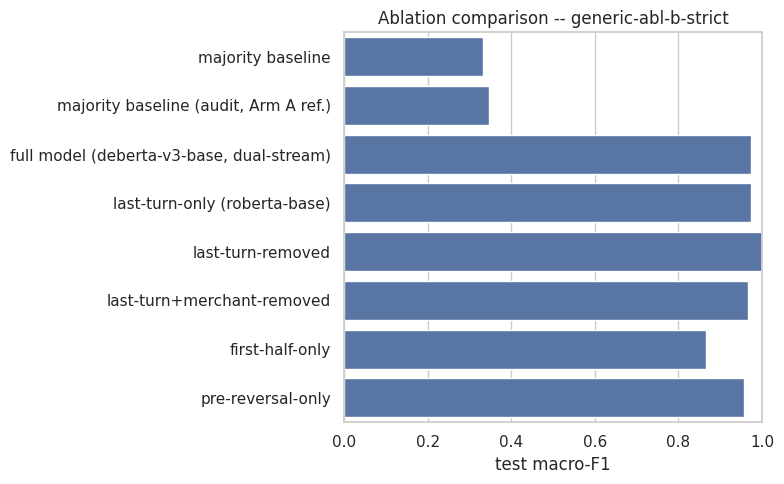

In [13]:
# =============================================================
# 8. RESULTS COMPARISON TABLE
# =============================================================
# ---- Hardcoded citations to Generic/ran-nb/AUDIT_generic-antiphony.md ----
# Section 4 (main results) and Section 6 (last-turn-only ablation).
# These numbers were NOT re-computed in this notebook -- see the design
# note in section 0 for why. They describe a run on the ORIGINAL
# 500-dialogue corpus only and should be treated as an Arm-A-only
# reference regardless of which arm this notebook is currently running.
AUDIT_MAJORITY_BASELINE = {"accuracy": 0.5333, "macro_f1": 0.3478}
AUDIT_FULL_MODEL = {  # deberta-v3-base, full dual-stream antiphony model
    "accuracy": 0.9733, "macro_f1": 0.9733}
AUDIT_LASTTURN_ONLY = {  # roberta-base, LastTurnClassifier control
    "accuracy": 0.9733, "macro_f1": 0.9732}
AUDIT_DIALOGUE_CONTRIBUTION_GAP = 0.0001   # full - last-turn-only, macro-F1

comparison_rows = [
    {"system": "majority baseline", "input": "none", "source": "this run",
     "accuracy": baseline_row["binary_accuracy"], "macro_f1": baseline_row["binary_macro_f1"]},
    {"system": "majority baseline (audit, Arm A ref.)", "input": "none",
     "source": "AUDIT_generic-antiphony.md §4",
     "accuracy": AUDIT_MAJORITY_BASELINE["accuracy"], "macro_f1": AUDIT_MAJORITY_BASELINE["macro_f1"]},
    {"system": "full model (deberta-v3-base, dual-stream)", "input": "full dialogue",
     "source": "AUDIT_generic-antiphony.md §4 (Arm A ref., NOT re-run here)",
     "accuracy": AUDIT_FULL_MODEL["accuracy"], "macro_f1": AUDIT_FULL_MODEL["macro_f1"]},
    {"system": "last-turn-only (roberta-base)", "input": "final Buyer turn ONLY",
     "source": "AUDIT_generic-antiphony.md §6 (Arm A ref., NOT re-run here)",
     "accuracy": AUDIT_LASTTURN_ONLY["accuracy"], "macro_f1": AUDIT_LASTTURN_ONLY["macro_f1"]},
    {"system": "last-turn-removed", "input": "full dialogue MINUS final Buyer turn",
     "source": "this run",
     "accuracy": result_lastturn_removed["test_binary_accuracy"],
     "macro_f1": result_lastturn_removed["test_binary_macro_f1"]},
    {"system": "last-turn+merchant-removed", "input": "full dialogue MINUS final Buyer turn "
     "and any trailing Merchant courtesy turn(s)", "source": "this run",
     "accuracy": result_lastmerch_removed["test_binary_accuracy"],
     "macro_f1": result_lastmerch_removed["test_binary_macro_f1"]},
    {"system": "first-half-only", "input": "first ~50% of turns", "source": "this run",
     "accuracy": result_first_half["test_binary_accuracy"],
     "macro_f1": result_first_half["test_binary_macro_f1"]},
]
if result_pre_reversal is not None:
    comparison_rows.append({
        "system": "pre-reversal-only", "input": "reversal-tagged dialogues, truncated before "
        "reversal_turn_id", "source": "this run",
        "accuracy": result_pre_reversal["test_binary_accuracy"],
        "macro_f1": result_pre_reversal["test_binary_macro_f1"]})
else:
    comparison_rows.append({
        "system": "pre-reversal-only", "input": "reversal-tagged dialogues, truncated before "
        "reversal_turn_id", "source": "this run",
        "accuracy": np.nan, "macro_f1": np.nan})

cmp_df = pd.DataFrame(comparison_rows)
cmp_df["macro_f1_over_baseline"] = (cmp_df["macro_f1"] - baseline_row["binary_macro_f1"]).round(4)
display(cmp_df.round(4))

removed_gap = AUDIT_FULL_MODEL["macro_f1"] - result_lastturn_removed["test_binary_macro_f1"]
print(f"\n{'='*72}")
print(f"NECESSITY gap (full model[audit] - last-turn-removed[this run]) "
      f"= {removed_gap:+.4f} macro-F1")
print(f"SUFFICIENCY gap (full model[audit] - last-turn-only[audit])      "
      f"= {AUDIT_DIALOGUE_CONTRIBUTION_GAP:+.4f} macro-F1  (cited, not re-computed)")
print(f"{'='*72}")
print("Reading these two gaps together:")
print("  - small SUFFICIENCY gap  -> the closing turn is enough on its own (already known).")
print("  - small NECESSITY gap   -> the rest of the dialogue can also fully substitute for")
print("    the closing turn once it's hidden. Both small at once means the label is")
print("    heavily over-determined in this corpus: it leaks from more than one place.")
print("  - small SUFFICIENCY gap + LARGE necessity gap is the interesting split-outcome:")
print("    the closing turn is sufficient (fast/explicit) but NOT redundant -- hide it and")
print("    the rest of the dialogue is not enough to recover it. That is what a corpus")
print("    with genuine reversals (Arm B / Arm C) is expected to surface.")

out_csv = os.path.join(CONFIG["out_dir"], f"results_summary_{CONFIG['run_tag']}.csv")
cmp_df.to_csv(out_csv, index=False)
print(f"\nSaved {out_csv}")

plt.figure(figsize=(8, 5))
plot_df = cmp_df.dropna(subset=["macro_f1"])
sns.barplot(data=plot_df, x="macro_f1", y="system", orient="h")
plt.xlim(0, 1); plt.xlabel("test macro-F1"); plt.ylabel("")
plt.title(f"Ablation comparison -- {CONFIG['run_tag']}")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], f"ablation_comparison_{CONFIG['run_tag']}.png"), dpi=150)
plt.show()


## 9. Reversal-flip diagnostic (sanity check)

For every reversal-tagged dialogue in the TEST split, checks whether the
`last-turn-removed` model's prediction flips to the **wrong, pre-reversal**
label — i.e. whether hiding the closing turn makes the model confidently
predict the sentiment the buyer held *before* they reversed. This is the
"does the ablation correctly get confused on reversal cases" check: a
control that never gets fooled by reversals either isn't a hard enough
control, or the model really is tracking trajectory well enough to survive
losing the closing line.

On the current 500-dialogue corpus this section reports **0 reversal-tagged
dialogues found** and stops there — expected at this stage, since no
dialogue in `final.json` carries `reversal_turn_id` yet. Re-run this cell
once Arm B / Arm C data is loaded.


In [14]:
# =============================================================
# 9. REVERSAL-FLIP DIAGNOSTIC (rewritten to read the side table)
# =============================================================
test_rid = test_df["dialogue_id"].map(reversal_meta["reversal_turn_id"])
n_reversal_test = int(test_rid.notna().sum())

if n_reversal_test == 0:
    print("No reversal-tagged dialogues in the TEST split for this corpus.")
else:
    print(str(n_reversal_test) + " reversal-tagged dialogue(s) in TEST. Re-scoring the "
          "last-turn-removed model on them.")
    rev_test_df = test_df[test_rid.notna()].reset_index(drop=True)
    rev_texts = [remove_last_buyer_turn(t, False) for t in rev_test_df["text"]]
    hf_id = CONFIG["ablation_encoder"]["hf_id"]
    tokenizer = AutoTokenizer.from_pretrained(hf_id)
    ckpt = os.path.join(CONFIG["out_dir"], CONFIG["checkpoint_dir_name"],
                        "ablation_last-turn-removed.pt")
    model = MinimalClassifier(hf_id, len(CONFIG["binary_classes"])).to(DEVICE)
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model.eval()
    enc = tokenizer(rev_texts, padding=True, truncation=True,
                    max_length=CONFIG["ablation_max_len_full"], return_tensors="pt")
    with torch.no_grad():
        logits = model(input_ids=enc["input_ids"].to(DEVICE),
                       attention_mask=enc["attention_mask"].to(DEVICE))
        preds = logits.argmax(-1).cpu().tolist()
        probs_yes = torch.softmax(logits, dim=-1)[:, yes_idx].cpu().tolist()
    del model; gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    diag_rows = []
    for i, row in rev_test_df.iterrows():
        did = row["dialogue_id"]
        true_label = row["binary_id"]
        diag_rows.append({
            "dialogue_id": did,
            "reversal_type": reversal_meta.loc[did, "reversal_type"],
            "reversal_turn_id": reversal_meta.loc[did, "reversal_turn_id"],
            "opening_tag": reversal_meta.loc[did, "opening_tag"],
            "true_label": CONFIG["binary_classes"][true_label],
            "predicted_label": CONFIG["binary_classes"][preds[i]],
            "prob_yes": round(probs_yes[i], 4),
            "flipped_to_pre_reversal_label": bool(preds[i] == 1 - true_label),
        })
    diag_df = pd.DataFrame(diag_rows)
    display(diag_df)
    n_flipped = int(diag_df["flipped_to_pre_reversal_label"].sum())
    print()
    print(str(n_flipped) + "/" + str(len(diag_df)) + " reversal dialogues: the "
          "last-turn-removed model predicted the WRONG, pre-reversal label.")
    diag_csv = os.path.join(CONFIG["out_dir"],
                            "reversal_flip_diagnostic_" + CONFIG["run_tag"] + ".csv")
    diag_df.to_csv(diag_csv, index=False)
    print("Saved " + diag_csv)

24 reversal-tagged dialogue(s) in TEST. Re-scoring the last-turn-removed model on them.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,dialogue_id,reversal_type,reversal_turn_id,opening_tag,true_label,predicted_label,prob_yes,flipped_to_pre_reversal_label
0,REV_085,commit_to_rejection,17.0,committed,no,no,0.0175,False
1,REV_113,commit_to_rejection,11.0,committed,no,no,0.0043,False
2,REV_115,commit_to_rejection,7.0,committed,no,no,0.0056,False
3,REV_097,commit_to_rejection,11.0,committed,no,no,0.0037,False
4,REV_012,resistance_to_agreement,5.0,resistant,yes,yes,0.9936,False
5,REV_093,commit_to_rejection,7.0,committed,no,no,0.0682,False
6,REV_082,commit_to_rejection,13.0,committed,no,no,0.0048,False
7,REV_035,resistance_to_agreement,9.0,resistant,yes,yes,0.9933,False
8,REV_127,commit_to_rejection,17.0,committed,no,no,0.0053,False
9,REV_062,resistance_to_agreement,11.0,resistant,yes,yes,0.9940,False



0/24 reversal dialogues: the last-turn-removed model predicted the WRONG, pre-reversal label.
Saved /kaggle/working/reversal_flip_diagnostic_generic-abl-b-strict.csv


## 10. Persisted run report

Saves a JSON summary (same convention as `run_report_<run_tag>.json` in
the source notebook) so results from Arm A / B / C can be diffed
programmatically later.


In [15]:
# =============================================================
# 10. PERSISTED RUN REPORT
# =============================================================
payload = {
    "run_tag": CONFIG["run_tag"],
    "dataset_path": dataset_path,
    "n_total": int(len(df)),
    "n_train": int(len(train_df)), "n_val": int(len(val_df)), "n_test": int(len(test_df)),
    "n_reversal_tagged_total": int(reversal_meta["reversal_turn_id"].notna().sum()),
    "n_reversal_tagged_test": int(n_reversal_test) if 'n_reversal_test' in dir() else 0,
    "baseline": baseline_row,
    "audit_reference_arm_a": {
        "majority_baseline": AUDIT_MAJORITY_BASELINE,
        "full_model_deberta_v3": AUDIT_FULL_MODEL,
        "last_turn_only_roberta": AUDIT_LASTTURN_ONLY,
        "dialogue_contribution_gap": AUDIT_DIALOGUE_CONTRIBUTION_GAP,
        "citation": "Generic/ran-nb/AUDIT_generic-antiphony.md",
    },
    "arms": {
        "last_turn_removed": {
            "accuracy": result_lastturn_removed["test_binary_accuracy"],
            "macro_f1": result_lastturn_removed["test_binary_macro_f1"]},
        "last_turn_plus_merchant_removed": {
            "accuracy": result_lastmerch_removed["test_binary_accuracy"],
            "macro_f1": result_lastmerch_removed["test_binary_macro_f1"]},
        "first_half_only": {
            "accuracy": result_first_half["test_binary_accuracy"],
            "macro_f1": result_first_half["test_binary_macro_f1"]},
        "pre_reversal_only": (
            {"accuracy": result_pre_reversal["test_binary_accuracy"],
             "macro_f1": result_pre_reversal["test_binary_macro_f1"]}
            if result_pre_reversal is not None else None),
    },
}
out_json = os.path.join(CONFIG["out_dir"], f"run_report_{CONFIG['run_tag']}.json")
with open(out_json, "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2)
print(f"Saved {out_json}")
print("\nArtefacts written to", CONFIG["out_dir"])
for f_ in sorted(os.listdir(CONFIG["out_dir"])):
    if CONFIG["run_tag"] in f_:
        print("  -", f_)


Saved /kaggle/working/run_report_generic-abl-b-strict.json

Artefacts written to /kaggle/working
  - ablation_comparison_generic-abl-b-strict.png
  - checkpoints_generic-abl-b-strict
  - results_summary_generic-abl-b-strict.csv
  - reversal_flip_diagnostic_generic-abl-b-strict.csv
  - run_report_generic-abl-b-strict.json


## 11. What to write up

Fill in after each arm's run (Arm A now; Arm B and Arm C after the
reversal dataset exists — see `Generic/ABLATION_STUDY_GUIDELINE.md`):

- **Necessity gap** (full model vs. last-turn-removed): ____
- **Sufficiency gap** (full model vs. last-turn-only, cited from the audit): 0.0001
- **first-half-only** macro-F1: ____ — does the opening alone also leak the label?
- **pre-reversal-only** macro-F1 (Arm B/C only): ____
- **Reversal-flip diagnostic** (Arm B/C only): ___/___ reversal dialogues flipped to the
  wrong, pre-reversal label once the closing turn was hidden.
- **Conclusion**: does the pattern across arms support "the dual-stream
  cross-attention + trajectory GRU are doing real trajectory-tracking
  work", or does it suggest the label keeps leaking through some other
  channel even with the closing turn hidden? See
  `Generic/ABLATION_STUDY_GUIDELINE.md` section 4 for the decision
  framework this maps onto.


In [16]:
# ============================================================= CONTROL
# MATCHED-CONTROL ANALYSIS.
# Within a single opening stance, compare reversal dialogues against the
# monotonic negatives that share that stance. This is the comparison the
# matched negatives were built for: if the arms cannot separate them, the
# opening stance carries no outcome information.
# =============================================================
if reversal_meta["opening_tag"].notna().sum() == 0:
    print("no stance annotation in this corpus -- control analysis not applicable.")
else:
    _tok = AutoTokenizer.from_pretrained(CONFIG["ablation_encoder"]["hf_id"])
    _rows = []
    _arms = {
        "last-turn-removed": [remove_last_buyer_turn(t, False) for t in test_df["text"]],
        "first-half-only":   [first_half_text(r["turns"]) for _, r in test_df.iterrows()],
    }
    for _name, _texts in _arms.items():
        _ck = os.path.join(CONFIG["out_dir"], CONFIG["checkpoint_dir_name"],
                           "ablation_" + re.sub(r'[^a-zA-Z0-9_.-]+', '_', _name) + ".pt")
        if not os.path.isfile(_ck):
            continue
        _m = MinimalClassifier(CONFIG["ablation_encoder"]["hf_id"],
                               len(CONFIG["binary_classes"])).to(DEVICE)
        _m.load_state_dict(torch.load(_ck, map_location=DEVICE))
        _m.eval()
        _pred = []
        for _s in range(0, len(_texts), 32):
            _e = _tok(_texts[_s:_s + 32], padding=True, truncation=True,
                      max_length=CONFIG["ablation_max_len_full"], return_tensors="pt")
            with torch.no_grad():
                _lg = _m(input_ids=_e["input_ids"].to(DEVICE),
                         attention_mask=_e["attention_mask"].to(DEVICE))
            _pred.extend(_lg.argmax(-1).cpu().tolist())
        del _m; gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        for _i, _r in test_df.iterrows():
            _did = _r["dialogue_id"]
            _rt = reversal_meta.loc[_did, "reversal_type"]
            _rows.append({
                "arm": _name, "dialogue_id": _did,
                "opening_tag": reversal_meta.loc[_did, "opening_tag"],
                "is_reversal": bool(pd.notna(reversal_meta.loc[_did, "reversal_turn_id"])),
                "reversal_type": _rt,
                "true": CONFIG["binary_classes"][_r["binary_id"]],
                "pred": CONFIG["binary_classes"][_pred[_i]],
                "correct": bool(_pred[_i] == _r["binary_id"]),
            })
    control_df = pd.DataFrame(_rows)
    if len(control_df) and control_df["opening_tag"].notna().any():
        _g = control_df[control_df["opening_tag"].notna()]
        print("accuracy within each opening stance, reversal vs matched negative:")
        piv = _g.groupby(["arm", "opening_tag", "is_reversal"]).agg(
            n=("correct", "size"), acc=("correct", "mean")).reset_index()
        display(piv)
        print()
        print("If an arm scores high on BOTH rows of a stance, the stance itself")
        print("is not what it is using. If it scores high on reversals and low on")
        print("the matched negatives, it is riding the opening stance.")
        _p = os.path.join(CONFIG["out_dir"], "matched_control_" + CONFIG["run_tag"] + ".csv")
        control_df.to_csv(_p, index=False)
        print("Saved " + _p)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


accuracy within each opening stance, reversal vs matched negative:


,arm,opening_tag,is_reversal,n,acc
0,first-half-only,committed,False,4,0.750000
1,first-half-only,committed,True,13,0.923077
2,first-half-only,resistant,False,2,1.000000
3,first-half-only,resistant,True,11,0.818182
4,last-turn-removed,committed,False,4,1.000000
5,last-turn-removed,committed,True,13,1.000000
6,last-turn-removed,resistant,False,2,1.000000
7,last-turn-removed,resistant,True,11,1.000000



If an arm scores high on BOTH rows of a stance, the stance itself
is not what it is using. If it scores high on reversals and low on
the matched negatives, it is riding the opening stance.
Saved /kaggle/working/matched_control_generic-abl-b-strict.csv
